In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from hydra import initialize, compose
from rdkit import Chem
from ergochemics.mapping import rc_to_nest, get_reaction_center
from cgr.ml import sep_aidx_to_bin_label, scrub_anonymous_template_atoms
from cgr.rule_writing import filter_by_pub_date
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    auc,
    average_precision_score
)

from sklearn.calibration import CalibrationDisplay

with initialize(version_base=None, config_path="../configs/filepaths"):
    cfg = compose(config_name="filepaths")

mlflow.set_tracking_uri(f"file://{cfg.mlruns}")

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 12,
    "axes.titlesize": 16,
})

In [2]:
def get_min_dist_to_rc(am_rxn: str, rc: list[list[list[int]], list[list[int]]]) -> list[list[list[int]], list[list[int]]]:
    mols = [[Chem.MolFromSmiles(elt) for elt in side.split('.')] for side in am_rxn.split('>>')]
    min_dists = [[], []]
    for i, side_rc in enumerate(rc):
        for mol, rc in zip(mols[i], side_rc):
            for atom in mol.GetAtoms():
                aidx = atom.GetIdx()
                min_dist = min(len(Chem.GetShortestPath(mol, aidx, rcidx)) - 1 if aidx != rcidx else 0 for rcidx in rc)

                min_dists[i].append(min_dist)
    return [np.array(elt).reshape(-1, 1) for elt in min_dists]


In [6]:
cutoff_date = 2015
experiment_name = f"before_{cutoff_date}"
experiment = mlflow.get_experiment_by_name(experiment_name)

if experiment:
    df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
else:
    print(f"Experiment '{experiment_name}' not found.")

df.head()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.train_loss,metrics.epoch,params.data/split_seed,params.training/batch_size,...,params.full/training/init_lr,params.warmup_epochs,params.full/training/pw_scl,params.final_lr,params.model/mp_d_h,params.init_lr,tags.mlflow.source.type,tags.mlflow.source.name,tags.mlflow.runName,tags.mlflow.user
0,c0c426556f634255bd3cdc93f92e58e9,741007712916749944,FINISHED,file:///home/stef/cgr/artifacts/mlruns/7410077...,2026-03-13 16:01:25.449000+00:00,2026-03-13 16:04:46.167000+00:00,0.089139,4.0,1234,113,...,0.0001,2,0.2727668128480795,0.001,293,0.0001,LOCAL,scripts/train_production.py,bouncy-goose-177,stef
1,640ff2d3ec874cfb993566549fff99f9,741007712916749944,FINISHED,file:///home/stef/cgr/artifacts/mlruns/7410077...,2026-03-13 15:57:06.897000+00:00,2026-03-13 16:00:38.206000+00:00,0.064440,5.0,1234,105,...,0.0001,2,0.16396370137134267,0.001,258,0.0001,LOCAL,scripts/train_production.py,honorable-snake-654,stef
2,e9d1a377171a47c8bf3f9e9891f40d09,741007712916749944,FINISHED,file:///home/stef/cgr/artifacts/mlruns/7410077...,2026-03-13 15:53:22.584000+00:00,2026-03-13 15:56:23.940000+00:00,0.052261,5.0,1234,102,...,0.0001,2,0.13062327097080317,0.001,235,0.0001,LOCAL,scripts/train_production.py,bustling-sheep-977,stef
3,77478272b2c743f092805f7816ecfda6,741007712916749944,FINISHED,file:///home/stef/cgr/artifacts/mlruns/7410077...,2026-03-13 15:49:05.363000+00:00,2026-03-13 15:52:36.957000+00:00,0.053027,5.0,1234,109,...,0.0001,2,0.13466689503759408,0.001,247,0.0001,LOCAL,scripts/train_production.py,upbeat-flea-947,stef
4,70db488705d64d73932a3add6c6e4a61,741007712916749944,FINISHED,file:///home/stef/cgr/artifacts/mlruns/7410077...,2026-03-13 15:45:04.709000+00:00,2026-03-13 15:48:21.637000+00:00,0.095373,5.0,1234,103,...,0.0001,2,0.2648477193605732,0.001,274,0.0001,LOCAL,scripts/train_production.py,righteous-skink-877,stef


In [7]:
preds = []
for _, row in df.iterrows():
    preds.append(
        pd.read_parquet(
            Path(row['artifact_uri'].replace("file:///home/spn1560/coarse-grain-rxns", "..")) / "predictions.parquet"
        )
    )

pred_df = pd.concat(preds, ignore_index=True)
pred_df.head()

,rxn_id,aidx,y,y_pred
0,1df0c98f185e6581109d26af4be03ea93c490d63,0,0.0,0.019849
1,1df0c98f185e6581109d26af4be03ea93c490d63,1,1.0,0.999586
2,1df0c98f185e6581109d26af4be03ea93c490d63,2,1.0,0.969697
3,1df0c98f185e6581109d26af4be03ea93c490d63,3,1.0,0.995053
4,1df0c98f185e6581109d26af4be03ea93c490d63,4,0.0,0.000787


In [8]:
# Filter by publication date
pub = pd.read_parquet(Path(cfg.raw_data) / "rxn_pub_dates.parquet")
pred_df = filter_by_pub_date(pub, pred_df, cutoff_date, mode="after")

In [9]:
roc_auc_score(pred_df['y'], pred_df['y_pred'])

np.float64(0.9961170589274403)

In [11]:
full = pd.read_parquet(
    Path(cfg.raw_data) / "mapped_known_reactions_x_mechinformed_rules.parquet"
)

full = filter_by_pub_date(pub, full, cutoff_date, mode="after")
full = full[full['rxn_id'].isin(pred_df['rxn_id'].unique())]
full["template_aidxs"] = full["template_aidxs"].apply(rc_to_nest)
full['template_aidxs'] = full.apply(lambda x: scrub_anonymous_template_atoms(x.template_aidxs, x.rule), axis=1) # Scrub anonymous atoms from aidxs
full["reaction_center"] = full["am_smarts"].apply(get_reaction_center) # Get the actual reaction center from the atom mapped reactions
full["min_dist_to_rc"] = full.apply(lambda x: get_min_dist_to_rc(x.am_smarts, x.reaction_center)[0], axis=1) # Get min dist to reaction center for lhs
full["binary_label"] = full.apply(lambda x: sep_aidx_to_bin_label(x.am_smarts, x.template_aidxs)[0], axis=1) # Convert aidxs to binary labels for block mol
full.head()

,rxn_id,smarts,am_smarts,rule,template_aidxs,rule_id,reaction_center,min_dist_to_rc,binary_label
4,1df0c98f185e6581109d26af4be03ea93c490d63,CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP...,[CH3:4][C:1](=[O:2])[S:10][CH2:11][CH2:12][NH:...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((1, 2, 3), (5,)), ((5, 6, 8), (47,)))",39,"[[[1, 3], [5]], [[6, 5], [47]]]","[[1], [0], [1], [0], [1], [2], [3], [4], [5], ...","[[0.0], [1.0], [1.0], [1.0], [0.0], [0.0], [0...."
14,28cfa1867efd23f5094c66ffc2c4cf90f5ae5f88,*C(=O)C(*)NC(C)=O.CC(C)(COP(=O)(O)OP(=O)(O)OCC...,[*:56][C:54](=[O:57])[CH:53]([*:55])[NH:52][C:...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((6, 8, 5), (47,)), ((1, 2, 3), (5,)))",40,"[[[6, 5], [47]], [[1, 3], [5]]]","[[3], [2], [3], [1], [2], [0], [0], [1], [1], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [1...."
20,cd98f98adb9f4d80fbf6f52f2d46a8c6296e0960,*C(=O)C(CC(=O)O)NC(=O)C(CC(=O)O)NC(=O)C(CC(=O)...,[*:72][C:70](=[O:73])[CH:67]([CH2:71][C:74](=[...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((25, 27, 24), (47,)), ((1, 2, 3), (20,)))",40,"[[[25, 24], [47]], [[1, 3], [20]]]","[[9], [8], [9], [7], [8], [9], [10], [10], [6]...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...."
21,bd05a1037b167e98722c573096e65edcf09eca81,CC(=O)SCCNC(=O)CCNC(=O)C(O)C(C)(C)COP(=O)(O)OP...,[CH3:4][C:1](=[O:2])[S:29][CH2:30][CH2:31][NH:...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((1, 2, 3), (20,)), ((24, 25, 27), (47,)))",39,"[[[1, 3], [20]], [[25, 24], [47]]]","[[1], [0], [1], [0], [1], [2], [3], [4], [5], ...","[[0.0], [1.0], [1.0], [1.0], [0.0], [0.0], [0...."
23,b99292634c3f7190595a6cedae8f95dd8a84789a,*C(=O)C(CC(=O)O)NC(=O)C(CCSC)NC(C)=O.O>>CSCCC(...,[*:17][C:15](=[O:18])[CH:14]([CH2:16][C:19](=[...,[C&D3&v4&H0&+0&!R&z2:1](=[O&D1&v2&H0&+0&!R:2])...,"(((9, 10, 8), (0,)), ((9, 10, 11), (4,)))",7,"[[[9, 8], [0]], [[9, 11], [4]]]","[[3], [2], [3], [1], [2], [3], [4], [4], [0], ...","[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...."


In [12]:
rdchiral_preds = pd.read_parquet(
    Path(cfg.processed_data) / "rdchiral_predictions.parquet"
)
print(f"Loaded rdchiral predictions with shape {rdchiral_preds.shape}")
rdchiral_preds = filter_by_pub_date(pub, rdchiral_preds, cutoff_date, mode="after")
rdchiral_preds = rdchiral_preds[rdchiral_preds['rxn_id'].isin(pred_df['rxn_id'].unique())]
print(f"Filtered rdchiral predictions to shape {rdchiral_preds.shape} after applying cutoff date filter")

rdchiral_metrics = {}
rdchiral_metrics['precision'] = precision_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['recall'] = recall_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['accuracy'] = accuracy_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)
rdchiral_metrics['f1'] = f1_score(
    y_true=rdchiral_preds['y'],
    y_pred=rdchiral_preds['y_pred']
)

rxn_recovery_indicator = []
rdchiral_rxn_recall = rdchiral_preds.groupby('rxn_id').apply(
    lambda x: int((x['y_pred'] - x['y'] >= 0).all())
)
rdchiral_metrics['rxn_recall'] = rdchiral_rxn_recall.sum() / len(rdchiral_rxn_recall)

print("Rdchiral prediction metrics:")
for k, v in rdchiral_metrics.items():
    print(f"{k}: {v:.4f}")

rdchiral_preds.head()

Loaded rdchiral predictions with shape (695370, 4)
Filtered rdchiral predictions to shape (79746, 4) after applying cutoff date filter
Rdchiral prediction metrics:
precision: 0.5184
recall: 0.8626
accuracy: 0.9088
f1: 0.6476
rxn_recall: 0.5969


/tmp/ipykernel_32873/1840052208.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rdchiral_rxn_recall = rdchiral_preds.groupby('rxn_id').apply(


,rxn_id,aidx,y,y_pred
140,1df0c98f185e6581109d26af4be03ea93c490d63,0,0.0,1
141,1df0c98f185e6581109d26af4be03ea93c490d63,1,1.0,1
142,1df0c98f185e6581109d26af4be03ea93c490d63,2,1.0,1
143,1df0c98f185e6581109d26af4be03ea93c490d63,3,1.0,1
144,1df0c98f185e6581109d26af4be03ea93c490d63,4,0.0,1


In [14]:
continuous_rxn_ids = []
for _, row in full.iterrows():
    continuous_rxn_ids.append(
        np.repeat(row["rxn_id"], row["binary_label"].shape[0]).reshape(-1, 1)
    )

continuous_rxn_ids = np.vstack(continuous_rxn_ids)

y = np.vstack(full["binary_label"])
min_dist_rc = np.vstack(full["min_dist_to_rc"])
Rs = [0, 1, 2, 3, 4]
rcr_preds = {R: (min_dist_rc <= R).astype(np.int32) for R in Rs}
recall_from_rcr = [recall_score(y, rcr_preds[R]) for R in Rs]
precision_from_rcr = [precision_score(y, rcr_preds[R]) for R in Rs]
recall_from_rcr, precision_from_rcr

([0.7181571815718157,
  0.8510775583946316,
  0.9210220673635308,
  0.9442508710801394,
  0.9908375274228933],
 [0.9941050375133976,
  0.5933957171135504,
  0.40438551759306474,
  0.304684572142411,
  0.2505629344385341])

In [15]:
recall_from_rcr, precision_from_rcr

([0.7181571815718157,
  0.8510775583946316,
  0.9210220673635308,
  0.9442508710801394,
  0.9908375274228933],
 [0.9941050375133976,
  0.5933957171135504,
  0.40438551759306474,
  0.304684572142411,
  0.2505629344385341])

GNN AUPRC: 0.9736625290053668
RC + R AUPRC: 0.8754929177977135


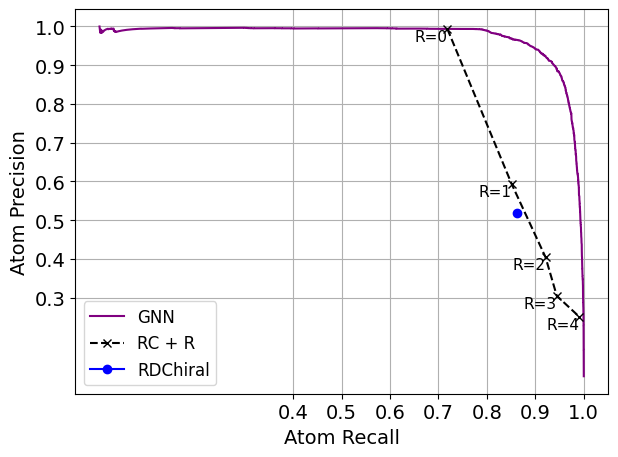

In [ ]:
# RC + R stats
r_labels = [f"R={i}" for i in range(len(recall_from_rcr))]

precision, recall, thresholds = precision_recall_curve(pred_df.y, pred_df.y_pred)
fig, ax = plt.subplots()
ax.plot(recall, precision, color='purple', label="GNN")
ax.plot(recall_from_rcr, precision_from_rcr, ls='--', marker="x", color='black', label="RC + R")
print("GNN AUPRC:", auc(recall, precision))
print("RC + R AUPRC:", auc([0] + recall_from_rcr, [precision_from_rcr[0]] + precision_from_rcr))
ax.plot(
    rdchiral_metrics['recall'],
    rdchiral_metrics['precision'],
    marker='o',
    color='blue',
    label='RDChiral'
)
ax.set_xticks(np.arange(0.4, 1.05, 0.1))
ax.set_yticks(np.arange(0.3, 1.05, 0.1))
# ax.set_xlim(0.5, 1.05)
ax.set_xlabel("Atom Recall")
ax.set_ylabel("Atom Precision")
for r, p, label in zip(recall_from_rcr, precision_from_rcr, r_labels):
    ax.text(r, p, label, fontsize=11, ha='right', va='top', color='black')
ax.grid()
ax.legend(loc='lower left')
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"atom_precision_recall_curve_{cutoff_date}_time_split.svg", format='svg')
plt.show()

In [17]:
ep = 3e-3
dts = []
for R, prec, rec_rcr in zip(Rs, precision_from_rcr, recall_from_rcr):
    print(f"Precision | {prec:.2f}")
    argequal_prec = np.flatnonzero(np.abs(precision - prec) < ep)[:-1]
    argmax_rec = np.argmax(recall[argequal_prec])
    print(f"Recall | GNN: {recall[argequal_prec][argmax_rec]:.2f} vs RC + {R}: {rec_rcr:.2f}")
    print(f"Threshold | {thresholds[argequal_prec][argmax_rec]:.3f}\n")
    dts.append(float(thresholds[argequal_prec][argmax_rec]))

print(dts)

Precision | 0.99
Recall | GNN: 0.79 vs RC + 0: 0.72
Threshold | 0.932

Precision | 0.59
Recall | GNN: 0.99 vs RC + 1: 0.85
Threshold | 0.069

Precision | 0.40
Recall | GNN: 1.00 vs RC + 2: 0.92
Threshold | 0.021

Precision | 0.30
Recall | GNN: 1.00 vs RC + 3: 0.94
Threshold | 0.009

Precision | 0.25
Recall | GNN: 1.00 vs RC + 4: 0.99
Threshold | 0.005

[0.9321246147155762, 0.06891476362943649, 0.020503388717770576, 0.009096325375139713, 0.0047616176307201385]


In [18]:
rxn_recall_from_rcr = []
for R in Rs:
    print(f"Calculating reaction recall from RCR for R={R}")
    preds = rcr_preds[R]
    rxn_recovery_indicator = []
    for rxn_id in tqdm(np.unique(continuous_rxn_ids), total=len(np.unique(continuous_rxn_ids)), desc="Processing reactions"):
        if (preds[continuous_rxn_ids == rxn_id] - y[continuous_rxn_ids == rxn_id] >= 0).all():
            rxn_recovery_indicator.append(1)
        else:
            rxn_recovery_indicator.append(0)
    
    rxn_recall_from_rcr.append(sum(rxn_recovery_indicator) / len(rxn_recovery_indicator))

Calculating reaction recall from RCR for R=0


Processing reactions: 100%|██████████| 1434/1434 [00:04<00:00, 330.43it/s]


Calculating reaction recall from RCR for R=1


Processing reactions: 100%|██████████| 1434/1434 [00:04<00:00, 312.83it/s]


Calculating reaction recall from RCR for R=2


Processing reactions: 100%|██████████| 1434/1434 [00:02<00:00, 559.35it/s] 


Calculating reaction recall from RCR for R=3


Processing reactions: 100%|██████████| 1434/1434 [00:04<00:00, 329.23it/s]


Calculating reaction recall from RCR for R=4


Processing reactions: 100%|██████████| 1434/1434 [00:04<00:00, 338.39it/s]


In [19]:
rxn_recall = []
ds = 1_000
for dt in tqdm(thresholds[::ds], total=len(thresholds[::ds]), desc="Calculating reaction recall from GNN"):
    rxn_recovery_indicator = []
    for rxn_id, group in pred_df.groupby("rxn_id"):
        preds = (group.y_pred >= dt).astype(np.int32).to_numpy()
        ytrue = group.y.to_numpy()
        if (preds - ytrue >= 0).all():
            rxn_recovery_indicator.append(1)
        else:
            rxn_recovery_indicator.append(0)

    rxn_recall.append(sum(rxn_recovery_indicator) / len(rxn_recovery_indicator))

Calculating reaction recall from GNN:   0%|          | 0/83 [00:00<?, ?it/s]

Calculating reaction recall from GNN: 100%|██████████| 83/83 [00:22<00:00,  3.66it/s]


GNN AUPRC: 0.8832306911637704
RC + R AUPRC: 0.6283964392877979


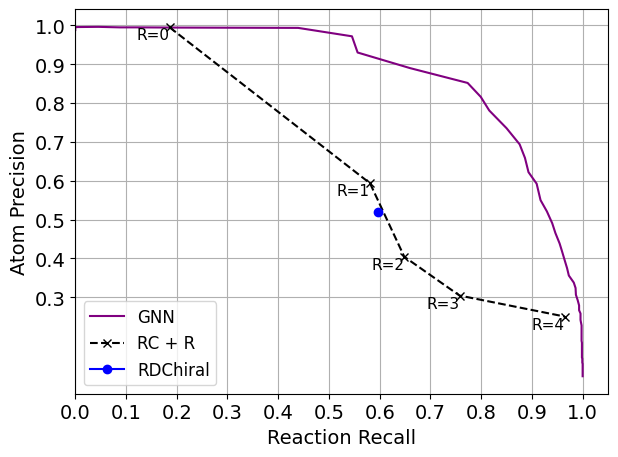

In [20]:
fig, ax = plt.subplots()
ax.plot(rxn_recall, precision[::ds], color='purple', label="GNN")
ax.plot(rxn_recall_from_rcr, precision_from_rcr, ls='--', marker="x", color='black', label="RC + R")
print("GNN AUPRC:", auc(rxn_recall, precision[::ds]))
print("RC + R AUPRC:", auc([0] + rxn_recall_from_rcr, [precision_from_rcr[0]] + precision_from_rcr))
ax.plot(
    rdchiral_metrics['rxn_recall'],
    rdchiral_metrics['precision'],
    marker='o',
    color='blue',
    label='RDChiral'
)
ax.set_xticks(np.arange(0.0, 1.05, 0.1))
ax.set_yticks(np.arange(0.3, 1.05, 0.1))
ax.set_xlim(0.0, 1.05)
ax.set_xlabel("Reaction Recall")
ax.set_ylabel("Atom Precision")
for r, p, label in zip(rxn_recall_from_rcr, precision_from_rcr, r_labels):
    ax.text(r, p, label, fontsize=11, ha='right', va='top', color='black')
ax.grid()
ax.legend(loc='lower left')
plt.tight_layout()
fig.savefig(Path(cfg.figures) / f"atom_precision_reaction_recall_curve_{cutoff_date}_time_split.svg", format='svg')
plt.show()